In [36]:
import pandas as pd
import numpy as np
import scipy
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro

In [37]:
end_date = datetime.today()
print(end_date)

2026-04-30 01:02:04.451118


In [38]:
start_date = end_date - timedelta(1*365)
print(start_date)

2025-04-30 01:02:04.451118


In [39]:
ticker_1 = ['^FTSE']
df_1 = yf.download(ticker_1, start = start_date, end = end_date, auto_adjust=False, actions=False)

[*********************100%***********************]  1 of 1 completed


In [40]:
df_1.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,,
2025-04-30,8494.900391,8494.900391,8494.900391,8430.500000,8463.500000,1589592400
2025-05-01,8496.799805,8496.799805,8505.299805,8468.299805,8494.900391,527568800
2025-05-02,8596.400391,8596.400391,8622.099609,8496.799805,8496.799805,908575200
2025-05-06,8597.400391,8597.400391,8641.700195,8569.099609,8596.400391,980036200
2025-05-07,8559.299805,8559.299805,8600.000000,8533.599609,8597.400391,1265512400


In [41]:
df_1['Adj Close']

Ticker,^FTSE
Date,
2025-04-30,8494.900391
2025-05-01,8496.799805
2025-05-02,8596.400391
2025-05-06,8597.400391
2025-05-07,8559.299805
...,...
2026-04-23,10457.000000
2026-04-24,10379.099609
2026-04-27,10321.099609


In [42]:
returns_1 = df_1['Adj Close'].pct_change().dropna()
returns_1

Ticker,^FTSE
Date,
2025-05-01,0.000224
2025-05-02,0.011722
2025-05-06,0.000116
2025-05-07,-0.004432
2025-05-08,-0.003236
...,...
2026-04-23,-0.001861
2026-04-24,-0.007450
2026-04-27,-0.005588


In [43]:
log_returns1 = np.log(1 + returns_1)
log_returns1

Ticker,^FTSE
Date,
2025-05-01,0.000224
2025-05-02,0.011654
2025-05-06,0.000116
2025-05-07,-0.004441
2025-05-08,-0.003242
...,...
2026-04-23,-0.001863
2026-04-24,-0.007477
2026-04-27,-0.005604


In [44]:
stat, p = stats.shapiro(log_returns1)
print(stat)
print(p)

0.9731224234411702
0.00010644777612655936


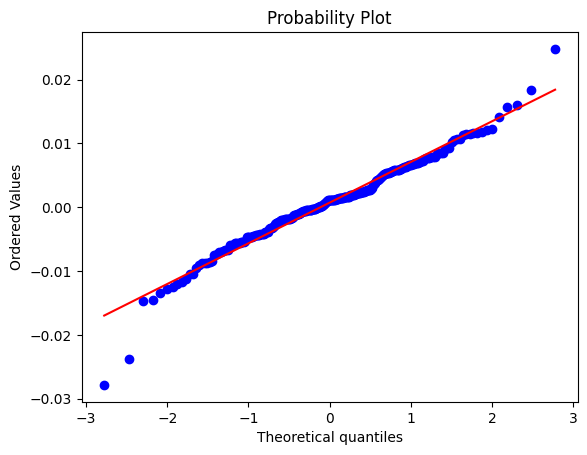

In [45]:
import scipy.stats as stats
x = log_returns1.squeeze().dropna()
stats.probplot(x, dist="norm", plot=plt)
plt.show()

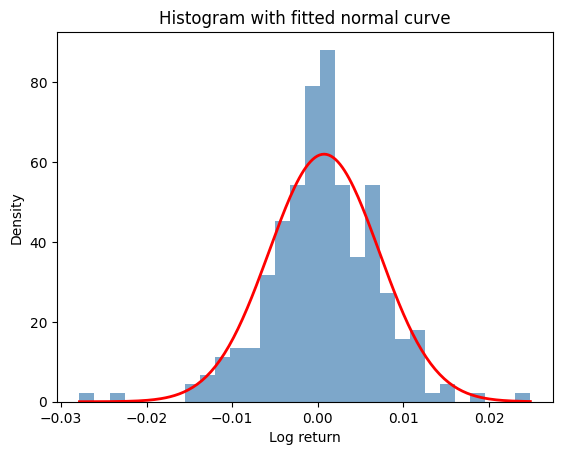

In [46]:
x = log_returns1.squeeze().dropna()

plt.hist(x, bins=30, density=True, alpha=0.7, color='steelblue')

mu = x.mean()
sigma = x.std()

x_vals = np.linspace(x.min(), x.max(), 200)
plt.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma), color='red', linewidth=2)

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Histogram with fitted normal curve")
plt.show()

In [54]:
tickers = ['^FCHI', '^GDAXI', '^N100']
df = yf.download(tickers, start = start_date, end = end_date, auto_adjust=False, actions=False)
stats_list = []
for ticker in tickers:
    prices = df['Adj Close'][ticker].dropna()
    returns = prices.pct_change(fill_method=None).dropna()
    log_returns = np.log(1+returns)
    stat, p = shapiro(log_returns)
    stats_list.append({
        'Ticker':ticker,
        'Mean':log_returns.mean(),
        'Std Dev':log_returns.std(),
        'Skewness':log_returns.skew(),
        'Kurtosis':log_returns.kurtosis(),
        'Shapiro Stat':stat,
        'p-value':p,
        'Conclusion':'Fail to Reject Normality' if p > 0.05 else 'Reject Normality'
    })
stats_df = pd.DataFrame(stats_list).round(7)
stats_df

[*********************100%***********************]  3 of 3 completed


,Ticker,Mean,Std Dev,Skewness,Kurtosis,Shapiro Stat,p-value,Conclusion
0,^FCHI,0.000240,0.008644,0.103786,3.472340,0.961233,0.000002,Reject Normality
1,^GDAXI,0.000249,0.009761,0.186505,2.962727,0.969933,0.000037,Reject Normality
2,^N100,0.000641,0.007806,-0.057182,2.686916,0.968605,0.000022,Reject Normality
